In [2]:
import duckdb
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [3]:
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]
DATABASE_PATH = "../../database/eBuS.duckdb"
OUTPUT_PATH = Path(r"C:\Users\Ralop\Nextcloud\Masterarbeit\Grafiken\FinalPlots")
#OUTPUT_PATH = Path(r"C:\Users\svens\Nextcloud\Masterarbeit\Grafiken\FinalPlots")
VEHICLE_DICT = {"Ebusco2.2electric12m": "Ebusco 2.2", "SolarisUrbino12electric": "Urbino 12", "SolarisUrbino18electric": "Urbino 18"}
SCENARIOS = ["summer", "winter", "reduced", "increased", "gridsoc"]
SEEDS = [65,67,68,70,75]

summer max active: 394 | min not stopped: 0


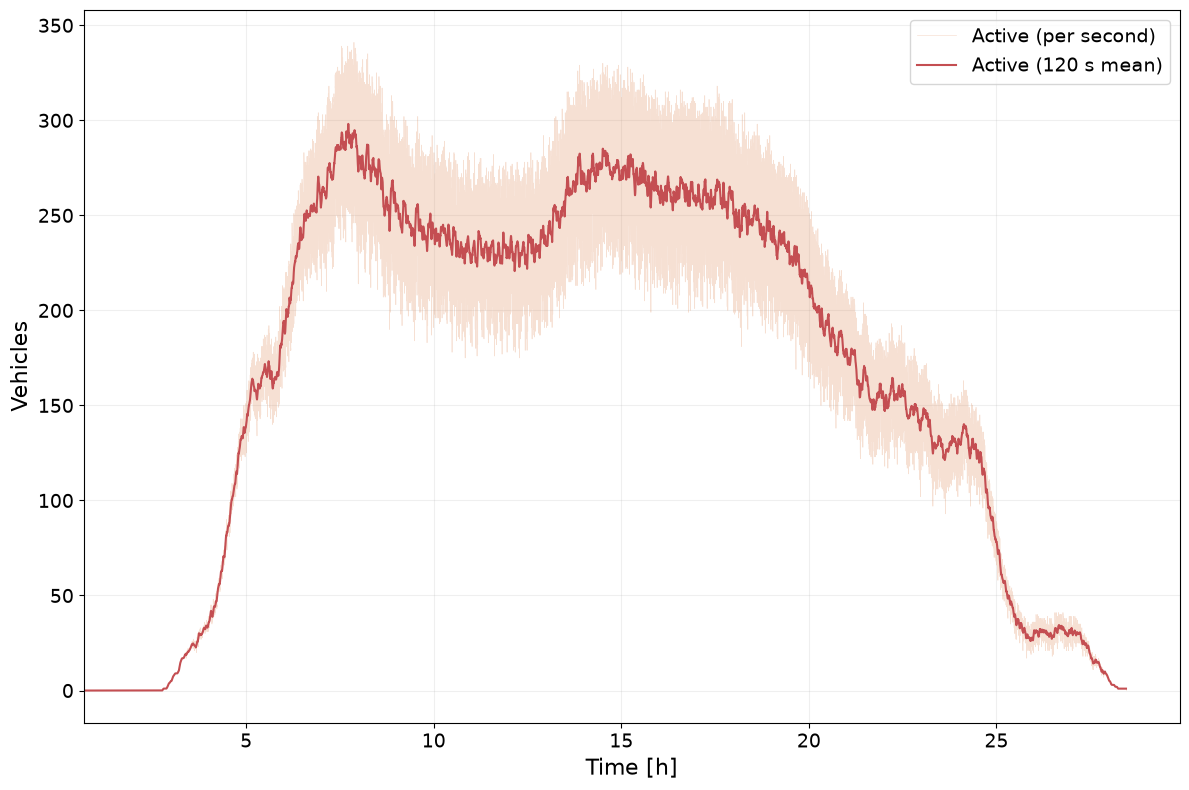

winter max active: 394 | min not stopped: 0


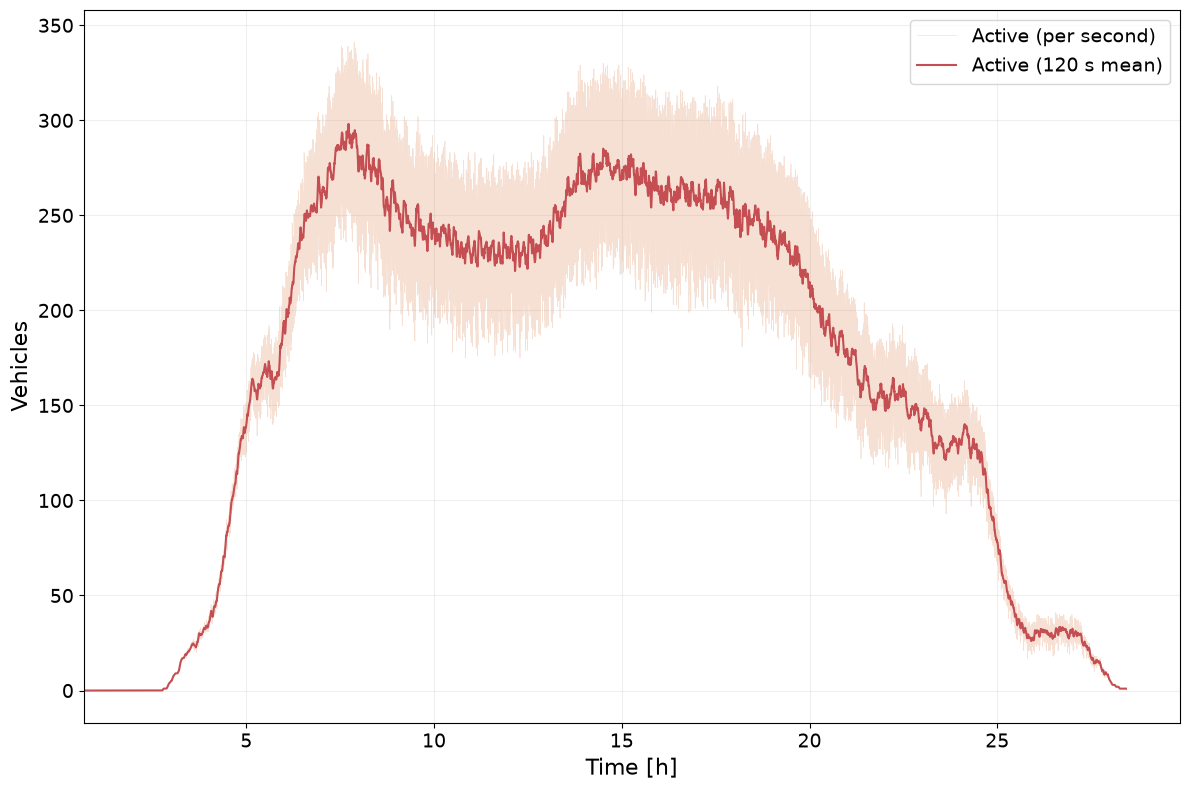

reduced max active: 394 | min not stopped: 0


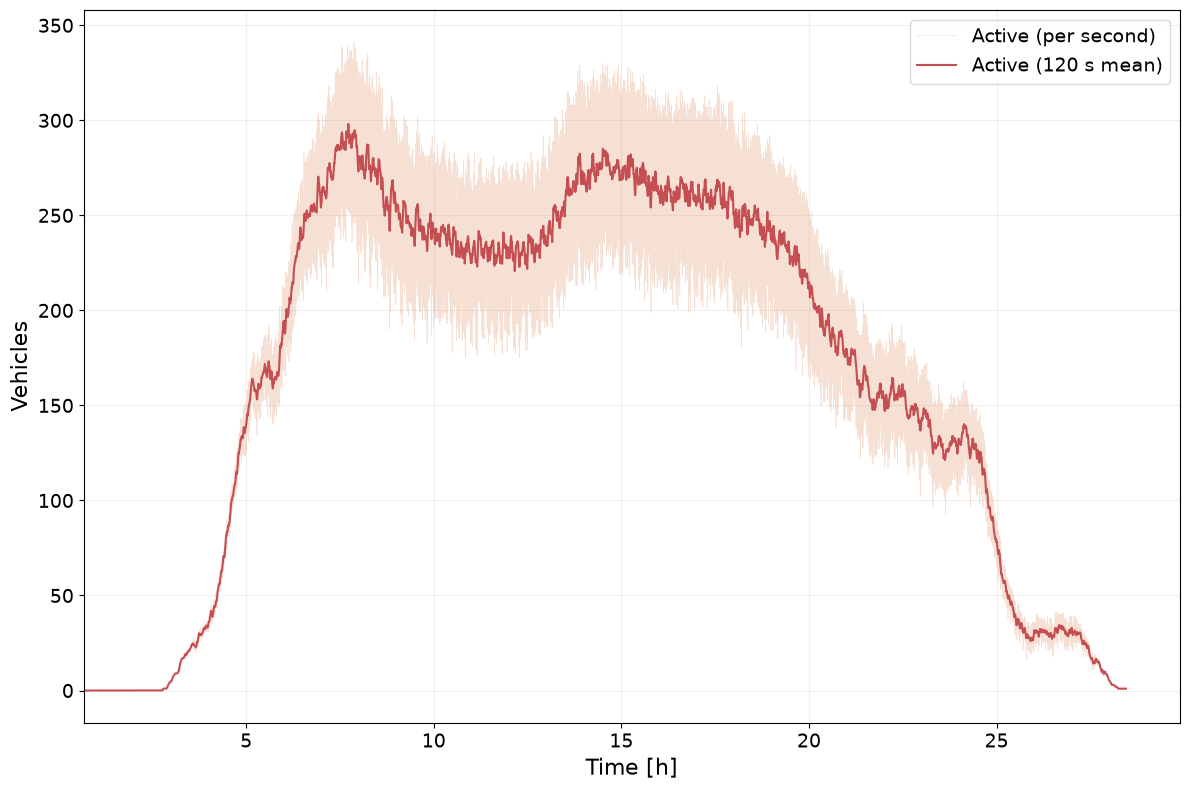

increased max active: 394 | min not stopped: 0


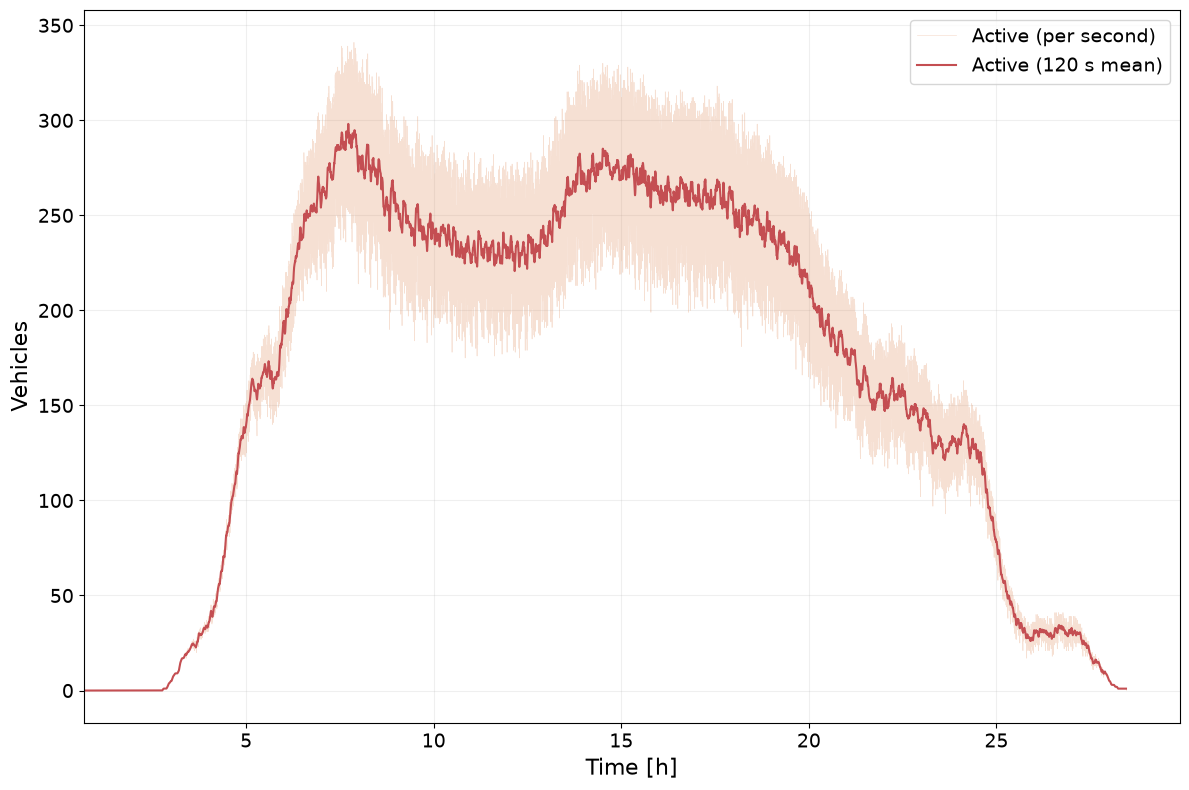

ValueError: zero-size array to reduction operation maximum which has no identity

In [4]:
STEP = 1  # seconds per timestep
SMOOTH_WINDOW = 120  # seconds
WARMUP = 2400

def vehicles_not_stopped_plot():
    con = duckdb.connect(DATABASE_PATH)

    stops = con.execute("""
        SELECT
            stopinfo_started,
            stopinfo_ended,
            scenario
        FROM multirun_stopinfo
        WHERE seed = 65
        AND stopinfo_ended - stopinfo_started > 21
    """).fetchdf()

    trips = con.execute("""
        SELECT
            tripinfo_id,
            tripinfo_depart,
            tripinfo_arrival,
            scenario
        FROM multirun_tripinfo_dedup
        WHERE seed = 65
    """).fetchdf()
    con.close()

    for scenario in SCENARIOS:
        s = stops[stops["scenario"] == scenario]
        s = s[s["stopinfo_started"] >= 0]
        tr = trips[trips["scenario"] == scenario]
        tr = tr[(tr["tripinfo_depart"] >= 0) & (tr["tripinfo_arrival"] >= 0)]


        stop_starts = np.sort(s["stopinfo_started"].to_numpy())
        stop_ends = np.sort(s.loc[s["stopinfo_ended"] >= 0, "stopinfo_ended"].to_numpy())
        departs = np.sort(tr["tripinfo_depart"].to_numpy())
        arrivals = np.sort(tr["tripinfo_arrival"].to_numpy())

        t = np.arange(0, arrivals.max() + STEP, STEP)

        # vehicles in the network: departed so far - arrived (removed) so far
        active = np.searchsorted(departs, t, side="right") - np.searchsorted(arrivals, t, side="right")
        # vehicles currently in a stop
        stopped = np.searchsorted(stop_starts, t, side="right") - np.searchsorted(stop_ends, t, side="right")

        not_stopped = pd.Series(active - stopped, index=t / 3600)
        smoothed = not_stopped.rolling(SMOOTH_WINDOW, center=True).mean()

        print(scenario, "max active:", active.max(), "| min not stopped:", not_stopped.min())

        fig, ax = plt.subplots(figsize=(12, 8))
        #ax.plot(t / 3600, active, color="grey", linewidth=0.8, label="active vehicles")
        ax.plot(not_stopped.index, not_stopped.values, alpha=0.25, linewidth=0.5, label="Active (per second)", color="#DD8452")
        ax.plot(smoothed.index, smoothed.values, linewidth=1.5, label=f"Active ({SMOOTH_WINDOW} s mean)", color= "#C44E52")
        ax.set_xlim(left=WARMUP / 3600)
        #ax.set_title(scenario)
        ax.set_xlabel("Time [h]", fontsize=16)
        ax.set_ylabel("Vehicles", fontsize=16)
        ax.tick_params(axis='y', labelsize=14)
        ax.tick_params(axis='x', labelsize=14)
        ax.legend(fontsize=14)
        ax.grid(alpha=0.2)
        plt.tight_layout()
        plt.show()

        fig.tight_layout()

        fig.savefig(
            OUTPUT_PATH / f"active_vehicles_over_time_{scenario}.pdf",
            format="pdf",
            bbox_inches="tight"
        )

    ax.grid(True)



vehicles_not_stopped_plot()